# Evaluasi Model Tradisional (TF-IDF)

Eksperimen ini melatih dan mengevaluasi beberapa model machine learning klasik (SVM, Random Forest, XGBoost, dan Logistic Regression) menggunakan fitur TF-IDF.

Metodologi yang digunakan:
1. **5-Fold Stratified Cross Validation** untuk menguji kestabilan performa model.
2. **Scikit-Learn Pipeline** untuk menghindari kebocoran data (data leakage) saat ekstraksi TF-IDF.
3. **Out-of-Fold (OOF) Predictions** untuk membuat Confusion Matrix dan laporan klasifikasi.

### 1. Import Library

Import library Python yang dibutuhkan untuk pemrosesan data, visualisasi, metrik evaluasi, dan model klasifikasi.

In [63]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from pathlib import Path
 
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
 
import xgboost as xgb


### 2. Konfigurasi Parameter Eksperimen

Pengaturan parameter seperti path dataset, nama kolom teks/sentimen, mapping label kelas, serta direktori untuk menyimpan model dan hasil visualisasi.

In [64]:
import os
from pathlib import Path

# Notebook ada di notebooks/ — pindah ke root project supaya semua path relatif bekerja
_cwd = Path(os.getcwd())
if _cwd.name == "notebooks":
    os.chdir(_cwd.parent)

DATA_PATH   = "Dataset/dataset_final_clean.csv"
TEXT_COL    = "text_cleaned"
LABEL_COL   = "sentiment"
LABEL_MAP   = {"Negative": 0, "Neutral": 1, "Positive": 2}
LABEL_NAMES = ["Negative", "Neutral", "Positive"]
MODEL_DIR   = "model_final"
RESULT_DIR  = "results"
SEED        = 42
N_FOLDS     = 5

print(f"Working dir: {os.getcwd()}")

Working dir: c:\BINUS\NLP\Research_paper\CS-IDX30 version 3\AOL_NLP


### 3. Memuat Dataset

Membaca dataset bersih hasil preprocessing dan menampilkan jumlah/distribusi data untuk masing-masing kelas target.

In [65]:
df     = pd.read_csv(DATA_PATH)
texts  = df[TEXT_COL].fillna("").tolist()
y      = np.array([LABEL_MAP[s] for s in df[LABEL_COL]])
 
print(f"{len(df)} records")
print(f"   Label dist: { {LABEL_NAMES[k]: int(v) for k, v in zip(*np.unique(y, return_counts=True))} }")

6120 records
   Label dist: {'Negative': 1445, 'Neutral': 1825, 'Positive': 2850}


### 4. Ekstraksi Fitur TF-IDF

Ekstraksi fitur menggunakan TF-IDF (Unigram dan Bigram) dengan pembatasan jumlah fitur maksimum, lalu menyimpan objek vectorizer ke folder model.

In [66]:
vectorizer = TfidfVectorizer(
    ngram_range     = (1, 2),       # unigram + bigram
    max_features    = 50000,        # top 50k features
    sublinear_tf    = True,         # log normalization untuk bantu data imbalanced
    min_df          = 2,            # buang term yang muncul < 2x
    strip_accents   = None,         # jangan strip jaga karakter Indonesia
    analyzer        = "word",
    token_pattern   = r"(?u)\b\w+\b",
)
 
X = vectorizer.fit_transform(texts)
print(f"Feature matrix: {X.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
 
# Simpan vectorizer untuk deploy nanti
Path(MODEL_DIR).mkdir(exist_ok=True)
joblib.dump(vectorizer, f"{MODEL_DIR}/tfidf_vectorizer.joblib")

Feature matrix: (6120, 24137)
Vocabulary size: 24,137


['model_final/tfidf_vectorizer.joblib']

## Bagian 2: Comprehensive Hyperparameter Tuning

Pencarian hyperparameter terbaik menggunakan **GridSearchCV** (SVM, LR) dan **RandomizedSearchCV** (RF, XGBoost) dengan 5-Fold Stratified CV. TF-IDF di-fix pada satu konfigurasi (30k features, min_df=3, unigram+bigram).

Parameter yang dituning:
- **SVM**: `C`
- **LR**: `C`, `penalty` (L1/L2)
- **RF**: `n_estimators`, `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`
- **XGBoost**: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha`, `reg_lambda`

In [67]:
import warnings; warnings.filterwarnings("ignore")
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import time

# Set True untuk train ulang (generate output bukti), False untuk load dari file
RETRAIN = False

tfidf = TfidfVectorizer(
    ngram_range=(1, 2), max_features=30_000, min_df=3,
    sublinear_tf=True, strip_accents=None,
    analyzer="word", token_pattern=r"(?u)\b\w+\b",
)
X_tfidf = tfidf.fit_transform(texts)
print(f"TF-IDF matrix: {X_tfidf.shape}")

if RETRAIN:
    skf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    search_results = {}

    print("\nSVM (LinearSVC + CalibratedClassifierCV)")
    t0 = time.time()
    svm_clf = CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=3000, random_state=SEED), cv=3)
    svm_search = GridSearchCV(svm_clf,
        {"estimator__C": [0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]},
        cv=skf_tune, scoring="f1_macro", n_jobs=1, verbose=1, return_train_score=True, refit=True)
    svm_search.fit(X_tfidf, y)
    search_results["SVM"] = svm_search
    print(f"Best: {svm_search.best_score_:.4f}  C={svm_search.best_params_['estimator__C']}  ({time.time()-t0:.0f}s)\n")

    print("Logistic Regression")
    t0 = time.time()
    lr_search = GridSearchCV(
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED),
        {"C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0], "penalty": ["l1", "l2"], "solver": ["saga"]},
        cv=skf_tune, scoring="f1_macro", n_jobs=-1, verbose=1, return_train_score=True, refit=True)
    lr_search.fit(X_tfidf, y)
    search_results["LR"] = lr_search
    bp = lr_search.best_params_
    print(f"Best: {lr_search.best_score_:.4f}  C={bp['C']}  penalty={bp['penalty']}  ({time.time()-t0:.0f}s)\n")

    print("Random Forest")
    t0 = time.time()
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=1),
        {"n_estimators": [200, 300, 500], "max_depth": [10, 15, 20, 30, None],
         "min_samples_leaf": [1, 2, 3, 5], "min_samples_split": [2, 5, 10], "max_features": ["sqrt", "log2"]},
        n_iter=30, cv=skf_tune, scoring="f1_macro", n_jobs=-1, verbose=1, return_train_score=True, refit=True, random_state=SEED)
    rf_search.fit(X_tfidf, y)
    search_results["RF"] = rf_search
    bp = rf_search.best_params_
    print(f"Best: {rf_search.best_score_:.4f}  depth={bp['max_depth']}  leaf={bp['min_samples_leaf']}  ({time.time()-t0:.0f}s)\n")

    print("XGBoost")
    t0 = time.time()
    xgb_search = RandomizedSearchCV(
        xgb.XGBClassifier(eval_metric="mlogloss", random_state=SEED, n_jobs=1, verbosity=0),
        {"n_estimators": [200, 300, 500], "max_depth": [3, 4, 5, 6, 8],
         "learning_rate": [0.01, 0.05, 0.1, 0.2], "subsample": [0.6, 0.7, 0.8, 0.9],
         "colsample_bytree": [0.6, 0.7, 0.8, 0.9], "min_child_weight": [1, 3, 5, 7],
         "reg_alpha": [0, 0.1, 0.5, 1.0], "reg_lambda": [0.5, 1.0, 2.0]},
        n_iter=30, cv=skf_tune, scoring="f1_macro", n_jobs=-1, verbose=1, return_train_score=True, refit=True, random_state=SEED)
    xgb_search.fit(X_tfidf, y)
    search_results["XGBoost"] = xgb_search
    bp = xgb_search.best_params_
    print(f"Best: {xgb_search.best_score_:.4f}  depth={bp['max_depth']}  lr={bp['learning_rate']}  ({time.time()-t0:.0f}s)\n")

    BEST_CV_RESULTS = {}
    for name, gs in search_results.items():
        best_idx = gs.best_index_
        val_f1   = gs.cv_results_["mean_test_score"][best_idx]
        val_std  = gs.cv_results_["std_test_score"][best_idx]
        train_f1 = gs.cv_results_["mean_train_score"][best_idx]
        gap      = train_f1 - val_f1
        BEST_CV_RESULTS[name] = {
            "val_f1": round(val_f1, 4), "std": round(val_std, 4),
            "train_f1": round(train_f1, 4), "gap": round(gap, 4),
            "params": gs.best_params_,
        }

    PIPELINES = {}
    Path("model_final").mkdir(exist_ok=True)
    NAME_MAP = {"SVM": "svm", "LR": "lr", "RF": "rf", "XGBoost": "xgboost"}
    for name, gs in search_results.items():
        best_clf = gs.best_estimator_
        pipe = Pipeline([("tfidf", TfidfVectorizer(**tfidf.get_params())), ("clf", best_clf)])
        pipe.fit(texts, y)
        path = f"model_final/pipeline_{NAME_MAP[name]}.joblib"
        joblib.dump(pipe, path)
        PIPELINES[name] = pipe

    model_info_data = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "note": "Pipeline(TF-IDF + model). Load & predict from raw text.",
        "label_map": LABEL_MAP, "label_names": LABEL_NAMES,
        "models": {name: {**r, "params": {k: str(v) for k, v in r["params"].items()},
                          "path": f"model_final/pipeline_{NAME_MAP[name]}.joblib"}
                   for name, r in BEST_CV_RESULTS.items()},
    }
    with open("model_final/model_info.json", "w", encoding="utf-8") as f:
        json.dump(model_info_data, f, indent=2, ensure_ascii=False)
    joblib.dump(tfidf, "model_final/tfidf_vectorizer_30k.joblib")

else:
    PIPELINES = {
        "SVM": joblib.load("model_final/pipeline_svm.joblib"),
        "LR": joblib.load("model_final/pipeline_lr.joblib"),
        "RF": joblib.load("model_final/pipeline_rf.joblib"),
        "XGBoost": joblib.load("model_final/pipeline_xgboost.joblib"),
    }
    with open("model_final/model_info.json") as f:
        BEST_CV_RESULTS = json.load(f)["models"]
    print("Loaded from saved models\n")

print(f"\n{'Model':<10} {'Val F1':>8} {'±std':>7} {'Train F1':>10} {'Gap':>8}")
print("-" * 45)
for name, r in BEST_CV_RESULTS.items():
    print(f"{name:<10} {r['val_f1']:>8.4f} {r['std']:>7.4f} {r['train_f1']:>10.4f} {r['gap']:>8.4f}")
best_model = max(BEST_CV_RESULTS, key=lambda k: BEST_CV_RESULTS[k]["val_f1"])
print(f"\nBest: {best_model} (Val F1 = {BEST_CV_RESULTS[best_model]['val_f1']:.4f})")
print("\nBest params:")
for name, r in BEST_CV_RESULTS.items():
    print(f"  {name}: {r['params']}")

TF-IDF matrix: (6120, 11848)
Loaded from saved models


Model        Val F1    ±std   Train F1      Gap
---------------------------------------------
SVM          0.6274  0.0126     0.8752   0.2477
LR           0.6638  0.0135     0.8902   0.2264
RF           0.6355  0.0142     0.8835   0.2481
XGBoost      0.6371  0.0098     0.9384   0.3013

Best: LR (Val F1 = 0.6638)

Best params:
  SVM: {'estimator__C': '0.3'}
  LR: {'C': '1.0', 'penalty': 'l2', 'solver': 'saga'}
  RF: {'n_estimators': '500', 'min_samples_split': '5', 'min_samples_leaf': '2', 'max_features': 'sqrt', 'max_depth': 'None'}
  XGBoost: {'subsample': '0.8', 'reg_lambda': '0.5', 'reg_alpha': '0.1', 'n_estimators': '500', 'min_child_weight': '1', 'max_depth': '6', 'learning_rate': '0.1', 'colsample_bytree': '0.7'}


In [68]:
import json, joblib
from pathlib import Path
from datetime import datetime

FINAL_DIR = "model_final"
Path(FINAL_DIR).mkdir(exist_ok=True)

NAME_MAP = {"SVM": "svm", "LR": "lr", "RF": "rf", "XGBoost": "xgboost"}
saved = {}

for name, gs in search_results.items():
    best_clf = gs.best_estimator_
    pipe = Pipeline([("tfidf", TfidfVectorizer(**tfidf.get_params())), ("clf", best_clf)])
    pipe.fit(texts, y)
    path = f"{FINAL_DIR}/pipeline_{NAME_MAP[name]}.joblib"
    joblib.dump(pipe, path)
    saved[name] = path
    print(f"[{name}] saved -> {path}")

model_info = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "note": "Pipeline(TF-IDF + model). Load & predict from raw text.",
    "label_map": LABEL_MAP,
    "label_names": LABEL_NAMES,
    "models": {},
}
for name in search_results:
    r = BEST_CV_RESULTS[name]
    params_str = {k: str(v) for k, v in r["params"].items()}
    model_info["models"][name] = {
        "val_f1": r["val_f1"], "std": r["std"],
        "train_f1": r["train_f1"], "gap": r["gap"],
        "params": params_str, "path": saved[name],
    }

with open(f"{FINAL_DIR}/model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)

joblib.dump(tfidf, f"{FINAL_DIR}/tfidf_vectorizer_30k.joblib")

print(f"\n{'Model':<10} {'Val F1':>8} {'Gap':>7}")
for name, r in BEST_CV_RESULTS.items():
    print(f"{name:<10} {r['val_f1']:>8.4f} {r['gap']:>7.4f}")


Model        Val F1     Gap
SVM          0.6274  0.2477
LR           0.6638  0.2264
RF           0.6355  0.2481
XGBoost      0.6371  0.3013


### Visualisasi Hasil

1. **Perbandingan Model** (`01_model_comparison.png`): Val F1 dan Overfit Gap semua model terbaik.
2. **Confusion Matrix OOF** (`03_confusion_matrices.png`): Confusion Matrix dari OOF predictions.

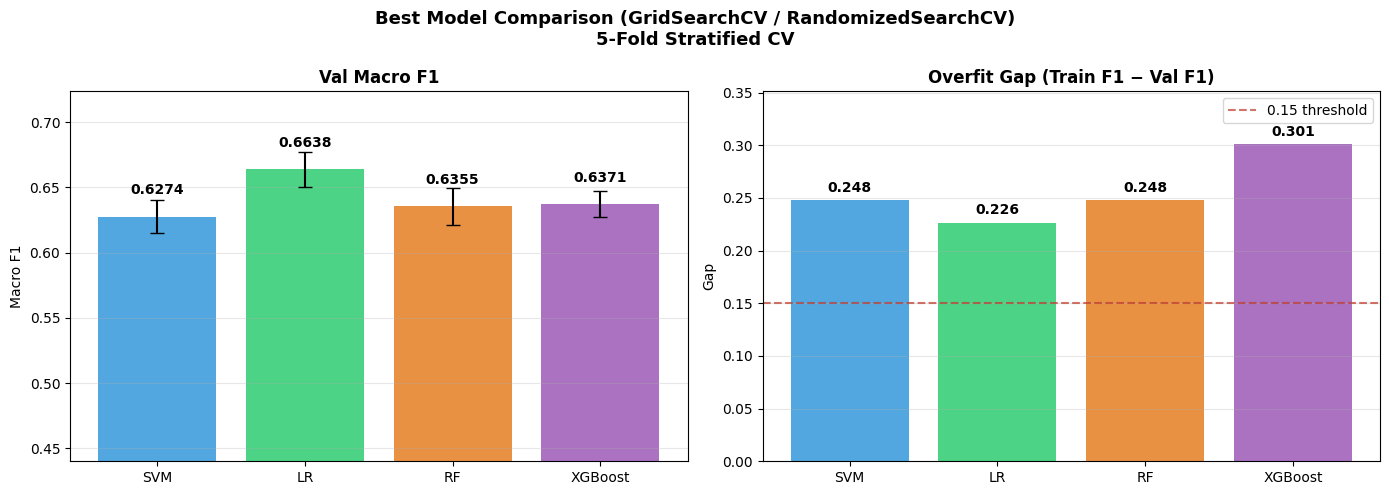

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

Path("results").mkdir(exist_ok=True)

model_names = list(BEST_CV_RESULTS.keys())
val_f1s = [BEST_CV_RESULTS[m]["val_f1"] for m in model_names]
val_stds = [BEST_CV_RESULTS[m]["std"] for m in model_names]
gaps = [BEST_CV_RESULTS[m]["gap"] for m in model_names]

x = np.arange(len(model_names))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Best Model Comparison (GridSearchCV / RandomizedSearchCV)\n5-Fold Stratified CV",
             fontsize=13, fontweight="bold")

# Val F1
bars1 = ax1.bar(x, val_f1s, color=colors, alpha=0.85, yerr=val_stds, capsize=5)
ax1.set_title("Val Macro F1", fontweight="bold")
ax1.set_xticks(x); ax1.set_xticklabels(model_names)
ax1.set_ylabel("Macro F1"); ax1.set_ylim(0.44, max(val_f1s) + 0.06)
ax1.grid(axis="y", alpha=0.3)
for bar, v in zip(bars1, val_f1s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f"{v:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Overfit Gap
bars2 = ax2.bar(x, gaps, color=colors, alpha=0.85)
ax2.axhline(0.15, color="#c0392b", linestyle="--", lw=1.5, alpha=0.7, label="0.15 threshold")
ax2.set_title("Overfit Gap (Train F1 − Val F1)", fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(model_names)
ax2.set_ylabel("Gap"); ax2.set_ylim(0, max(gaps) + 0.05)
ax2.grid(axis="y", alpha=0.3); ax2.legend()
for bar, v in zip(bars2, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
fig.savefig("results/01_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

OOF loaded from cache
  SVM: Macro F1 = 0.6241
  LR: Macro F1 = 0.6593
  RF: Macro F1 = 0.6351
  XGBoost: Macro F1 = 0.6353


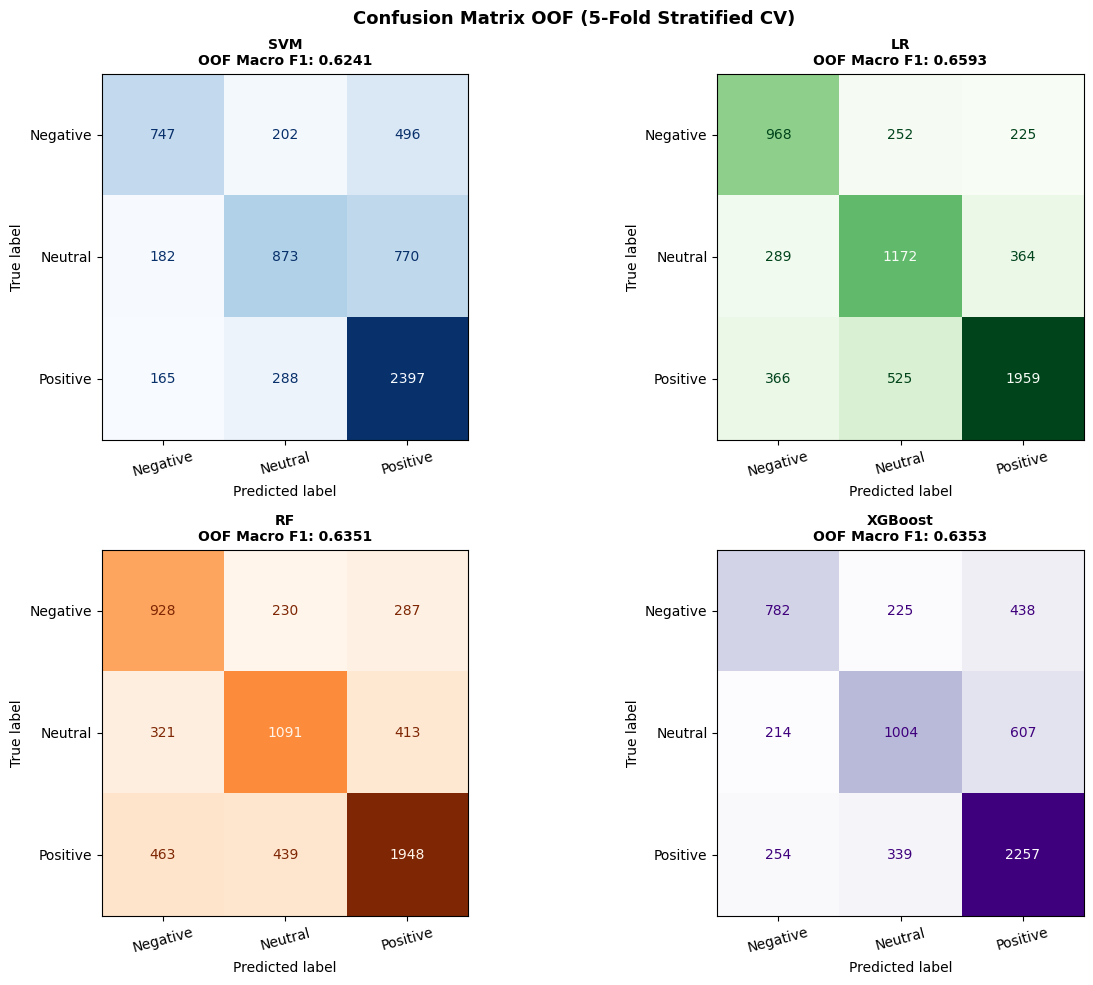


SOFT VOTING ENSEMBLE (4 model)
  Macro F1  : 0.6558
  Accuracy  : 0.6758

Model             Macro F1   Accuracy
-------------------------------------
SVM                 0.6241     0.6564
LR                  0.6593     0.6698
RF                  0.6351     0.6482
XGBoost             0.6353     0.6606
-------------------------------------
Ensemble            0.6558     0.6758

Delta vs Best Single: -0.0035

Classification Report - Soft Voting Ensemble:
              precision    recall  f1-score   support

    Negative     0.6330    0.5945    0.6131      1445
     Neutral     0.6416    0.5836    0.6112      1825
    Positive     0.7129    0.7761    0.7432      2850

    accuracy                         0.6758      6120
   macro avg     0.6625    0.6514    0.6558      6120
weighted avg     0.6727    0.6758    0.6731      6120



In [72]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, classification_report

OOF_CACHE = "model_final/oof_cache.joblib"

if Path(OOF_CACHE).exists():
    oof_cache = joblib.load(OOF_CACHE)
    oof_probs = oof_cache["probs"]
    oof_preds = oof_cache["preds"]
    oof_cms   = oof_cache["cms"]
    print("OOF loaded from cache")
    for name in oof_preds:
        print(f"  {name}: Macro F1 = {f1_score(y, oof_preds[name], average='macro'):.4f}")
else:
    skf_cm = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_probs = {}
    oof_preds = {}
    oof_cms = {}

    for name, pipe in PIPELINES.items():
        print(f"{name}", end=" ", flush=True)
        y_proba = cross_val_predict(pipe, texts, y, cv=skf_cm, method="predict_proba",
                                    n_jobs=1 if "SVM" in name else -1)
        y_pred = np.argmax(y_proba, axis=1)
        oof_probs[name] = y_proba
        oof_preds[name] = y_pred
        oof_cms[name] = confusion_matrix(y, y_pred)
        print(f"F1={f1_score(y, y_pred, average='macro'):.4f}")

    joblib.dump({"probs": oof_probs, "preds": oof_preds, "cms": oof_cms}, OOF_CACHE)

# OOF F1 scores (leak-free)
oof_f1s = {name: f1_score(y, pred, average="macro") for name, pred in oof_preds.items()}

# Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Confusion Matrix OOF (5-Fold Stratified CV)", fontsize=13, fontweight="bold")
cmaps = ["Blues", "Greens", "Oranges", "Purples"]
for ax, (name, cm_data), cmap in zip(axes.flat, oof_cms.items(), cmaps):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_data, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\nOOF Macro F1: {oof_f1s[name]:.4f}",
                 fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig("results/03_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# Ensemble
avg_proba = np.mean(list(oof_probs.values()), axis=0)
y_ensemble = np.argmax(avg_proba, axis=1)
ensemble_f1  = f1_score(y, y_ensemble, average="macro")
ensemble_acc = accuracy_score(y, y_ensemble)

print(f"\nSOFT VOTING ENSEMBLE (4 model)")
print(f"  Macro F1  : {ensemble_f1:.4f}")
print(f"  Accuracy  : {ensemble_acc:.4f}")

print(f"\n{'Model':<15} {'Macro F1':>10} {'Accuracy':>10}")
print("-" * 37)
for name, pred in oof_preds.items():
    print(f"{name:<15} {f1_score(y, pred, average='macro'):>10.4f} {accuracy_score(y, pred):>10.4f}")
print("-" * 37)
print(f"{'Ensemble':<15} {ensemble_f1:>10.4f} {ensemble_acc:>10.4f}")

best_single_f1 = max(f1_score(y, p, average="macro") for p in oof_preds.values())
print(f"\nDelta vs Best Single: {ensemble_f1 - best_single_f1:+.4f}")

print(f"\nClassification Report - Soft Voting Ensemble:")
print(classification_report(y, y_ensemble, target_names=LABEL_NAMES, digits=4))

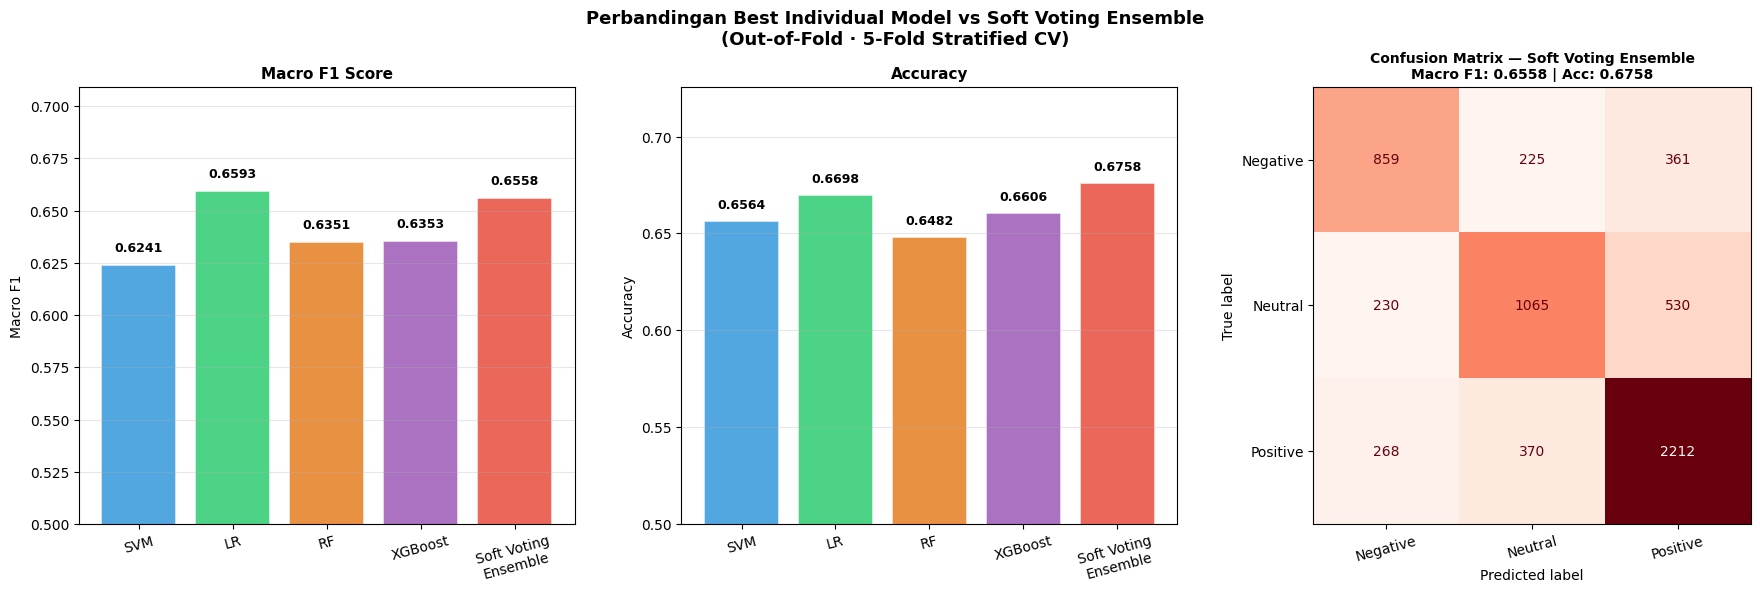


Classification Report — Soft Voting Ensemble:
              precision    recall  f1-score   support

    Negative     0.6330    0.5945    0.6131      1445
     Neutral     0.6416    0.5836    0.6112      1825
    Positive     0.7129    0.7761    0.7432      2850

    accuracy                         0.6758      6120
   macro avg     0.6625    0.6514    0.6558      6120
weighted avg     0.6727    0.6758    0.6731      6120



In [71]:
# Visualisasi: Bar chart perbandingan + Confusion Matrix Ensemble

model_names = list(oof_preds.keys()) + ["Soft Voting\nEnsemble"]
f1_scores   = [f1_score(y, p, average="macro") for p in oof_preds.values()] + [ensemble_f1]
acc_scores  = [accuracy_score(y, p) for p in oof_preds.values()] + [ensemble_acc]
colors      = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Perbandingan Best Individual Model vs Soft Voting Ensemble\n"
    "(Out-of-Fold · 5-Fold Stratified CV)",
    fontsize=13, fontweight="bold",
)

# Panel 1: Macro F1
ax1 = axes[0]
bars1 = ax1.bar(model_names, f1_scores, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
ax1.set_title("Macro F1 Score", fontweight="bold", fontsize=11)
ax1.set_ylabel("Macro F1")
ax1.set_ylim(0.50, max(f1_scores) + 0.05)
ax1.grid(axis="y", alpha=0.3)
for bar, v in zip(bars1, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{v:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.tick_params(axis="x", rotation=15)

# Panel 2: Accuracy
ax2 = axes[1]
bars2 = ax2.bar(model_names, acc_scores, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
ax2.set_title("Accuracy", fontweight="bold", fontsize=11)
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.50, max(acc_scores) + 0.05)
ax2.grid(axis="y", alpha=0.3)
for bar, v in zip(bars2, acc_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{v:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.tick_params(axis="x", rotation=15)

# Panel 3: Confusion Matrix Ensemble
ax3 = axes[2]
cm_ens = confusion_matrix(y, y_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=LABEL_NAMES)
disp.plot(ax=ax3, colorbar=False, cmap="Reds")
ax3.set_title(f"Confusion Matrix — Soft Voting Ensemble\nMacro F1: {ensemble_f1:.4f} | Acc: {ensemble_acc:.4f}",
              fontweight="bold", fontsize=10)
ax3.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig("results/04_ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Classification report ensemble
print("\nClassification Report — Soft Voting Ensemble:")
print(classification_report(y, y_ensemble, target_names=LABEL_NAMES, digits=4))